In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Lasso                  # LEAR baseline
from sklearn.multioutput import MultiOutputRegressor    # multi-horizon Lasso
from sklearn.metrics import mean_absolute_error         # shared metric for all models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore') 

2. Load the data + format dates

In [2]:
# Load Data
df = pd.read_csv('Full_Dataset.csv')

# Parse European dates and set as the timeline index
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y %H:%M')
df.set_index('Date', inplace=True)

# Sort out missing values
print("Missing values before cleaning:")
print(df.isna().sum())
df.interpolate(method='linear', inplace=True)
df.bfill(inplace=True) 
print("\nMissing values after cleaning:")
print(df.isna().sum())

# Keep only data from 2023 onwards
df = df.loc['2023-01-01':] 

print(f"Total hours of data: {len(df)}")
df.head(3)

Missing values before cleaning:
Price_BE      0
Load_FR       3
Gen_FR      292
Price_CH      0
Wind_BE       5
Solar_BE      5
Load_BE       0
dtype: int64

Missing values after cleaning:
Price_BE    0
Load_FR     0
Gen_FR      0
Price_CH    0
Wind_BE     0
Solar_BE    0
Load_BE     0
dtype: int64
Total hours of data: 27630


,Price_BE,Load_FR,Gen_FR,Price_CH,Wind_BE,Solar_BE,Load_BE
Date,,,,,,,
2023-01-01 00:00:00,-1.75,44900.0,42169.75,-7.25,2165.0250,0.0,7593.496667
2023-01-01 01:00:00,-1.46,43750.0,42059.50,-3.99,2165.3225,0.0,7315.745000
2023-01-01 02:00:00,-5.27,40400.0,40808.50,-7.71,2165.7050,0.0,7068.387500


3.0 Plot the correlation between all 

array([[<Axes: xlabel='Price_BE', ylabel='Price_BE'>,
        <Axes: xlabel='Load_FR', ylabel='Price_BE'>,
        <Axes: xlabel='Gen_FR', ylabel='Price_BE'>,
        <Axes: xlabel='Price_CH', ylabel='Price_BE'>,
        <Axes: xlabel='Wind_BE', ylabel='Price_BE'>,
        <Axes: xlabel='Solar_BE', ylabel='Price_BE'>,
        <Axes: xlabel='Load_BE', ylabel='Price_BE'>],
       [<Axes: xlabel='Price_BE', ylabel='Load_FR'>,
        <Axes: xlabel='Load_FR', ylabel='Load_FR'>,
        <Axes: xlabel='Gen_FR', ylabel='Load_FR'>,
        <Axes: xlabel='Price_CH', ylabel='Load_FR'>,
        <Axes: xlabel='Wind_BE', ylabel='Load_FR'>,
        <Axes: xlabel='Solar_BE', ylabel='Load_FR'>,
        <Axes: xlabel='Load_BE', ylabel='Load_FR'>],
       [<Axes: xlabel='Price_BE', ylabel='Gen_FR'>,
        <Axes: xlabel='Load_FR', ylabel='Gen_FR'>,
        <Axes: xlabel='Gen_FR', ylabel='Gen_FR'>,
        <Axes: xlabel='Price_CH', ylabel='Gen_FR'>,
        <Axes: xlabel='Wind_BE', ylabel='Gen_FR'>,
   

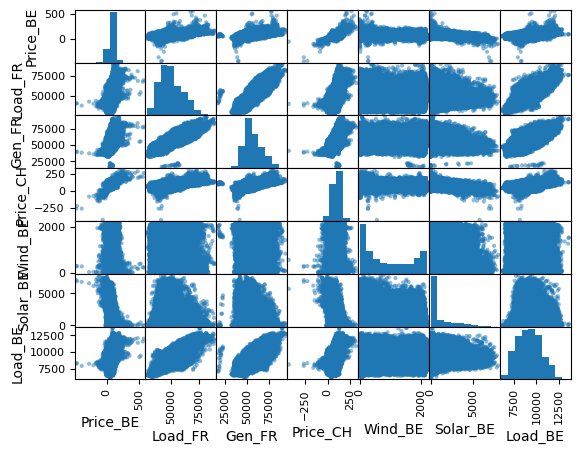

In [3]:
pd.plotting.scatter_matrix(df)

3. Data scaling and definition of the sliding window for model training 
- the target data is isolated (BE prices) 
- data is scaled between 0 and 1 (normalised)
- The sliding window is defined (= the amount of data that is used for prediction)

In [4]:
# === Cyclic calendar features ===
# Sin/cos encoding preserves cyclicity (hour 23 is 'close' to hour 0).
# Added directly to df so MinMaxScaler treats them alongside market features.
df['hour_sin']  = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos']  = np.cos(2 * np.pi * df.index.hour / 24)
df['dow_sin']   = np.sin(2 * np.pi * df.index.dayofweek / 7)
df['dow_cos']   = np.cos(2 * np.pi * df.index.dayofweek / 7)
df['month_sin'] = np.sin(2 * np.pi * (df.index.month - 1) / 12)
df['month_cos'] = np.cos(2 * np.pi * (df.index.month - 1) / 12)

# 7 original market features + 6 cyclic calendar encodings = 13 features total.
# Everything downstream uses len(features), so no other cell needs changing.
features = ['Price_BE', 'Gen_FR', 'Load_FR', 'Price_CH', 'Load_BE', 'Solar_BE', 'Wind_BE',
            'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

multivariate_data = df[features].values

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(multivariate_data)

def create_multivariate_sequences(data, look_back, predict_ahead):
    X, y = [], []
    for i in range(len(data) - look_back - predict_ahead + 1):
        X.append(data[i : (i + look_back), :])
        y.append(data[i + look_back : (i + look_back + predict_ahead), 0])
    return np.array(X), np.array(y)

LOOK_BACK = 168     
PREDICT_AHEAD = 72  

X, y = create_multivariate_sequences(scaled_data, LOOK_BACK, PREDICT_AHEAD)

print(f"X (Inputs) shape: {X.shape}") 
print(f"y (Targets) shape: {y.shape}")

X (Inputs) shape: (27391, 168, 13)
y (Targets) shape: (27391, 72)


4. Data split between the data used for training vs. validation

In [5]:
split_ratio = 0.8
split_index = int(len(X) * split_ratio)

X_train, X_val = X[:split_index], X[split_index:]
y_train, y_val = y[:split_index], y[split_index:]

print(f"Training on {len(X_train)} windows.")
print(f"Validating on {len(X_val)} windows.")

Training on 21912 windows.
Validating on 5479 windows.


5. Building + training of the LSTM model 

In [6]:
model = Sequential()

# First LSTM Layer
model.add(LSTM(units=64, return_sequences=True, input_shape=(LOOK_BACK, len(features))))
model.add(Dropout(0.2)) # Drops 20% of neurons randomly to prevent overfitting

# Second LSTM Layer
model.add(LSTM(units=32, return_sequences=False))
model.add(Dropout(0.2))

# Output Layer
model.add(Dense(units=PREDICT_AHEAD))

# MAE loss: less sensitive to extreme price spikes than MSE,
# which would over-penalise rare but large errors.
model.compile(optimizer='adam', loss='mae')

# Patience raised to 15: gives the model more room to escape local minima
# before early stopping kicks in.
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("Starting training...")
history = model.fit(
    X_train, y_train,
    epochs=50, 
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)
print("Training Complete!")


Starting training...
Epoch 1/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - loss: 0.1017 - val_loss: 0.0269
Epoch 2/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - loss: 0.0476 - val_loss: 0.0339
Epoch 3/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 19s 56ms/step - loss: 0.0384 - val_loss: 0.0256
Epoch 4/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 19s 56ms/step - loss: 0.0329 - val_loss: 0.0240
Epoch 5/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - loss: 0.0296 - val_loss: 0.0248
Epoch 6/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 19s 57ms/step - loss: 0.0274 - val_loss: 0.0217
Epoch 7/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - loss: 0.0259 - val_loss: 0.0220
Epoch 8/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - loss: 0.0240 - val_loss: 0.0195
Epoch 9/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 19s 56ms/step - loss: 0.0227 - val_loss: 0.0204
Epoch 10/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - loss: 0.0222 - val_loss: 0.0198
Epoch 11/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - loss: 0.0218 - val_loss: 0.0204
Epoch 12/

6. Check for overfitting
--> creates graph showing Training MSE vs Validation MSE (If the orange line starts going up while the blue line goes down, model is overfitting)

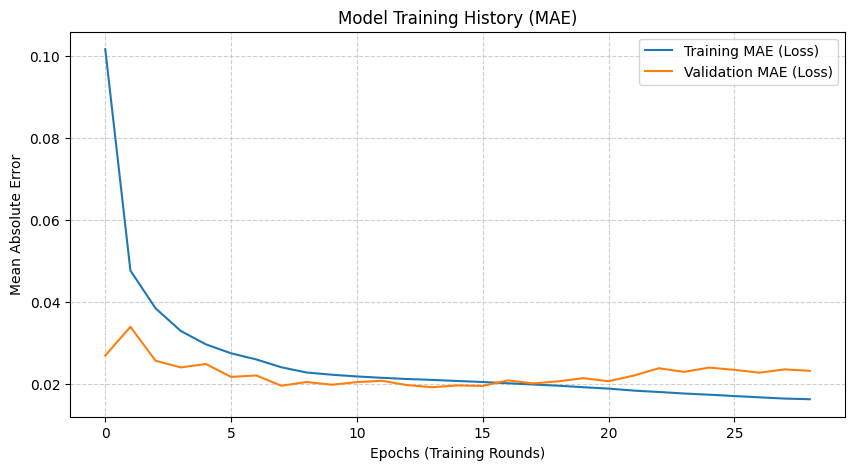

In [7]:
# Plotting the Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training MAE (Loss)')
plt.plot(history.history['val_loss'], label='Validation MAE (Loss)')
plt.title('Model Training History (MAE)')
plt.xlabel('Epochs (Training Rounds)')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

6b. Baseline Models: Persistence & LEAR
- **Persistence**: price at t+h ≈ price at t+h-72 (72 h ago). Trivial floor to beat.
- **LEAR**: Lasso-Enhanced AutoRegressive model — sparse linear regression over key price lags + calendar features.

In [8]:
# === Baseline 1: Persistence ===
# Forecast for hour t+h is simply the price at t+h-72 (same hour, 72 h earlier).
# This is the minimum benchmark: any useful model must beat it.
prices_raw = df['Price_BE'].values   # unscaled real prices in €/MWh

# n_total mirrors the number of LSTM samples (same sliding window logic)
n_total = len(prices_raw) - LOOK_BACK - PREDICT_AHEAD + 1

# Actual prices for every validation window (ground truth)
y_prices_all  = np.array([prices_raw[i+LOOK_BACK : i+LOOK_BACK+PREDICT_AHEAD]
                           for i in range(n_total)])

# Persistence prediction: the 72 h immediately before the prediction window
y_persist_all = np.array([prices_raw[i+LOOK_BACK-PREDICT_AHEAD : i+LOOK_BACK]
                           for i in range(n_total)])

# Use the same train/val split index as the LSTM for a fair comparison
y_prices_val  = y_prices_all[split_index:]
y_persist_val = y_persist_all[split_index:]

persist_mae = mean_absolute_error(y_prices_val, y_persist_val)
print(f"Persistence baseline MAE: {persist_mae:.2f} €/MWh")


# === Baseline 2: LEAR (Lasso-Enhanced AutoRegressive) ===
# Flat feature vector per sample: 8 key price lags + 6 cyclic calendar features
# at the start of the prediction window.
# A MultiOutputRegressor wraps Lasso to predict all 72 horizons simultaneously.

def build_lear_features(prices, df_index, i, look_back, predict_ahead):
    """Return a flat 1-D feature vector for sample i."""
    t = i + look_back  # index of the first prediction hour

    # Price lags: 1h, 24h, 48h, 72h, 96h, 120h, 144h, 168h before prediction start
    lag_vals = [prices[t - lag] for lag in [1, 24, 48, 72, 96, 120, 144, 168]]

    # Cyclic calendar features at the prediction start hour
    dt = df_index[t]
    cal = [
        np.sin(2*np.pi*dt.hour/24),        np.cos(2*np.pi*dt.hour/24),
        np.sin(2*np.pi*dt.dayofweek/7),     np.cos(2*np.pi*dt.dayofweek/7),
        np.sin(2*np.pi*(dt.month-1)/12),    np.cos(2*np.pi*(dt.month-1)/12),
    ]
    return lag_vals + cal

# Build the full flat feature matrix and raw-price targets
X_lear = np.array([build_lear_features(prices_raw, df.index, i, LOOK_BACK, PREDICT_AHEAD)
                   for i in range(n_total)])
y_lear = y_prices_all   # raw €/MWh targets (same windows as LSTM)

# Align train/val split with the LSTM split
X_lear_train, X_lear_val = X_lear[:split_index], X_lear[split_index:]
y_lear_train, y_lear_val = y_lear[:split_index], y_lear[split_index:]

# Fit one Lasso model per horizon via MultiOutputRegressor (n_jobs=-1 = all CPU cores)
lear_model = MultiOutputRegressor(Lasso(alpha=0.1, max_iter=5000), n_jobs=-1)
lear_model.fit(X_lear_train, y_lear_train)

y_lear_pred = lear_model.predict(X_lear_val)
lear_mae = mean_absolute_error(y_lear_val, y_lear_pred)
print(f"LEAR baseline MAE:        {lear_mae:.2f} €/MWh")

Persistence baseline MAE: 26.38 €/MWh
LEAR baseline MAE:        25.31 €/MWh


7. Final Test & Export 
This cell generates the actual assignment submission. It grabs the very last 168 hours of the dataset, asks the trained model to predict the next 72 hours, undoes the scaling (so the prices are back in Euros), and saves it to a CSV flawlessly.

In [9]:
# Generate predictions.csv

# 1. Grab the very last 168 hours of ALL features
last_168_hours = scaled_data[-LOOK_BACK:]

# 2. Reshape it so the neural network accepts it: (1 window, 168 hours, 6 features)
last_window = last_168_hours.reshape(1, LOOK_BACK, len(features))

# 3. Make the 72-hour prediction
scaled_prediction = model.predict(last_window)

# 4. The Dummy Array Trick for Inverse Transforming
dummy_array = np.zeros((PREDICT_AHEAD, len(features)))

# ...and insert our 72 predictions into the 0th column (which is Price_BE)
dummy_array[:, 0] = scaled_prediction.flatten()

# Inverse transform the whole table, but only extract the first column (our real Euro prices!)
final_prices = scaler.inverse_transform(dummy_array)[:, 0]

# 5. Format it EXACTLY as the assignment demands: 72 rows, 1 column
submission_df = pd.DataFrame(final_prices)

# 6. Export with NO index and NO header
submission_df.to_csv('predictions.csv', index=False, header=False)

print("\nSUCCESS! Saved to predictions.csv")
print("Check the file: It should have exactly 72 rows, 1 column, and no text headers.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step

SUCCESS! Saved to predictions.csv
Check the file: It should have exactly 72 rows, 1 column, and no text headers.


8. Prediction and uncertainty

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Running Monte Carlo simulations for P10/P90...


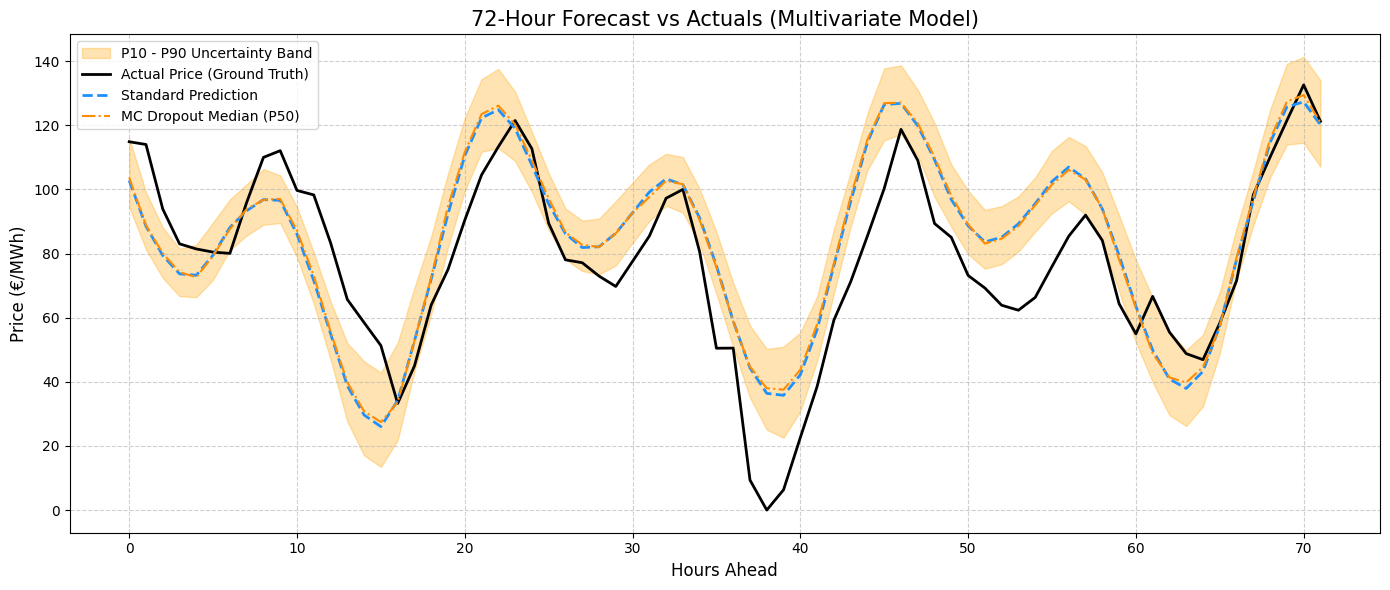

Mean Squared Error (MSE): 289.57500019235255
Mean Absolute Error (MAE): 14.35411647844646


In [11]:
#Prediction vs Actual with Uncertainty 

# 0. Helper function to use the "Dummy Array Trick" on any 1D prediction
from sklearn.metrics import mean_squared_error


def inverse_transform_target(scaled_1d_array):
    # Create a blank table of zeros (72 rows, 5 columns)
    dummy = np.zeros((len(scaled_1d_array), len(features)))
    # Put our scaled prices into the 0th column
    dummy[:, 0] = scaled_1d_array.flatten()
    # Inverse transform and return just the 0th column (Euros!)
    return scaler.inverse_transform(dummy)[:, 0]

# 1. Pick a random window from our validation set to test
sample_index = 100 
X_sample = X_val[sample_index : sample_index + 1]
y_actual_scaled = y_val[sample_index]

# 2. Get the Actual prices using our new helper function
y_actual = inverse_transform_target(y_actual_scaled)

# 3. Get the Standard Point Prediction
y_pred_scaled = model.predict(X_sample)
y_pred = inverse_transform_target(y_pred_scaled[0])

# --- MONTE CARLO DROPOUT FOR P10/P90 ---
print("Running Monte Carlo simulations for P10/P90...")
n_iterations = 100
mc_predictions = []

for _ in range(n_iterations):
    # Force Dropout ON
    mc_pred_scaled = model(X_sample, training=True).numpy()[0]
    # Inverse transform the simulation using the helper function
    mc_pred = inverse_transform_target(mc_pred_scaled)
    mc_predictions.append(mc_pred)

mc_predictions = np.array(mc_predictions)

# Calculate Percentiles
p10 = np.percentile(mc_predictions, 10, axis=0).flatten()
p50 = np.percentile(mc_predictions, 50, axis=0).flatten()
p90 = np.percentile(mc_predictions, 90, axis=0).flatten()

# --- PLOTTING ---
plt.figure(figsize=(14, 6))
hours = range(PREDICT_AHEAD)

plt.fill_between(hours, p10, p90, color='orange', alpha=0.3, label='P10 - P90 Uncertainty Band')
plt.plot(hours, y_actual, label='Actual Price (Ground Truth)', color='black', linewidth=2)
plt.plot(hours, y_pred, label='Standard Prediction', color='dodgerblue', linestyle='--', linewidth=2)
plt.plot(hours, p50, label='MC Dropout Median (P50)', color='darkorange', linestyle='-.')

plt.title('72-Hour Forecast vs Actuals (Multivariate Model)', fontsize=15)
plt.xlabel('Hours Ahead', fontsize=12)
plt.ylabel('Price (€/MWh)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Assuming y_actual and y_pred are already defined and denormalized
mse = mean_squared_error(y_actual, y_pred)
mae = mean_absolute_error(y_actual, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")

In [13]:
import pandas as pd

# 1. Grab the very last 168 hours of your SCALED dataset
last_168_hours = scaled_data[-168:] 

# 2. Reshape it for the LSTM: (1 sample, 168 time steps, X features)
final_input = last_168_hours.reshape(1, 168, len(features))

# 3. Predict the future (May 12 - 14)
future_prediction_scaled = model.predict(final_input)

# 4. Denormalize using the dummy array trick (scaler expects all feature columns)
dummy_array = np.zeros((PREDICT_AHEAD, len(features)))
dummy_array[:, 0] = future_prediction_scaled.flatten()
future_prediction_euros = scaler.inverse_transform(dummy_array)[:, 0]

# 5. Save exactly 72 rows and 1 column to a CSV with no headers
final_df = pd.DataFrame(future_prediction_euros)
final_df.to_csv('predictions.csv', index=False, header=False)

print("predictions.csv successfully generated for submission!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
predictions.csv successfully generated for submission!


9. Model Comparison Table
Evaluate all three models on the same validation set and report MAE in €/MWh.

In [14]:
# === LSTM MAE on the full validation set ===
# Run the model over every validation window and inverse-transform back to €/MWh.
y_lstm_pred_scaled  = model.predict(X_val, verbose=0)
y_lstm_pred_euros   = np.array([inverse_transform_target(y_lstm_pred_scaled[i])
                                 for i in range(len(y_lstm_pred_scaled))])
y_lstm_actual_euros = np.array([inverse_transform_target(y_val[i])
                                 for i in range(len(y_val))])
lstm_mae = mean_absolute_error(y_lstm_actual_euros, y_lstm_pred_euros)

# === Comparison table ===
# Goal: LSTM < LEAR < Persistence (not guaranteed, but the target ranking).
print("=" * 42)
print(f"{'Model':<25} {'MAE (€/MWh)':>12}")
print("-" * 42)
print(f"{'Persistence baseline':<25} {persist_mae:>12.2f}")
print(f"{'LEAR baseline':<25} {lear_mae:>12.2f}")
print(f"{'LSTM (this model)':<25} {lstm_mae:>12.2f}")
print("=" * 42)

Model                      MAE (€/MWh)
------------------------------------------
Persistence baseline             26.38
LEAR baseline                    25.31
LSTM (this model)                19.69
